This project will use U.S. quarterly GDP growth rates from 2010 to 2023 using three methods: 
least squares linear regression, polynomial fitting, and cubic spline interpolation. Using data published by 
the U.S. Bureau of Economic Analysis (BEA), I will compare how well each method models economic trends over time.

Part A - Cubic Spline Interpolation

1.

For the full dataset of n = 55 data points, I can define a cubic polynomial on each interval between data points as:

$S_i(x) = a_i +b_i(x - x_i) + c_i(x - x_i)^2 + d_i(x - x_i)^3$

with i = 1, 2, ..., n - 1, and $x_i = i$ is the quarter index and $y_i$ is the GDP growth rate for that value.
Each interval has 4 coefficients, a<sub>i</sub>, b<sub>i</sub>, c<sub>i</sub>, and d<sub>i</sub>, and there are n - 1 = 54 intervals,
so there are a total of 4(54) = 216 unknowns.

The spline must go through every data point, so $2(n - 1) = 108$ interpolation conditions:

$S_i(x_i) = y_i,\; S_i(x_{i+1}) = y_{i+1}$

The spline has to be smooth at the interior knots, giving us $n - 2 = 53$ conditions:

$S_i'(x_{i+1}) = S_{i+1}'(x_{i+1})$

The second derivative must be continuous at each interior knot, giving another $n - 2 = 53$ conditions:

$S_i''(x_{i+1}) = S_{i+1}''(x_{i+1})$

The natural boundary conditions make it so that the spline has zero curvature at the endpoints:

$S_1''(x_1) = 0,\; S_{54}''(x_{55}) = 0$


The data points are equally spaced, so the spline on each interval is:

$S_i(x) = \frac{M_i}{6}(x_{i+1} - x)^3 + \frac{M_{i+1}}{6}(x - x_i)^3 + \left(y_i - \frac{M_i}{6}\right)(x_{i+1} - x) + \left(y_{i+1} - \frac{M_{i+1}}{6}\right)(x - x_i)$

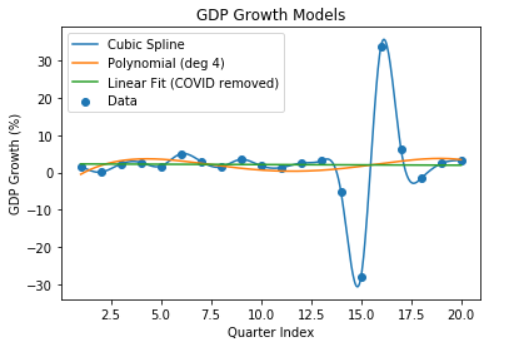



2.

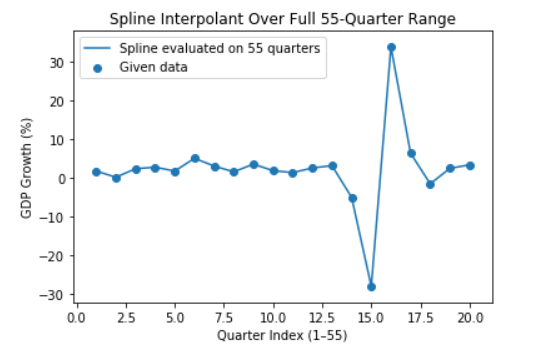

While the spline isn't visually smooth, it is mathematically smooth. This makes sense because cubic splines are continuous in the first and second derivatives, which means there is no sudden changes in slope or curvature. However, there are sharp changes during 2020 Q2, because the spline has to interpolate the values exactly, which results in a steep, continuous curve.

3.

The Runge phenomenon is when you use high-degree polynomial interpolation leads to oscillating behavior, especially near the boundaries of an interval or when there is a large variation in the data. It makes the function behave unrealistically even though it matches the data.

With exact interpolation, the interpolant passes through every point exactly. In a dataset with extreme outliers, this causes the function to turn very sharply. So while you have perfect fits at data points, it isn't very reliable everywhere else.

With numerical stability, the function approximates data rather than forcing an exact fit. In a dataset with extreme outliers, the outliers only affect a local area.  So while you gain smoothness and reliability, you lose exactness at the outlier points.

Smoothing splines would be preferable here, they best fit scenarios with long-term trends that have smooth curves. I want numerical stability, and with weighted least squares, just one outlier can change the entire curve if the weights are not chosen carefully.

Part B - Polynomial & Least Squares Comparison

1.

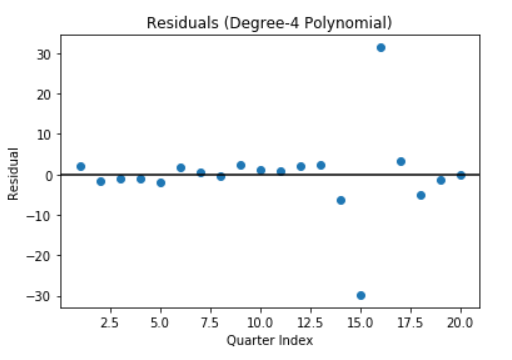

From the plot, the degree-4 polynomial captures the overall trend better than the cubic spline. It gives a broad view of the change of GDP over time, and doesn't include any local changes, better for someone looking at overall change.

The cubic spline reproduces specific data points better than the degree-4 polynomial. It includes all the local peaks, dips, and the outlier at 2020 Q2. This lets it analyze short-term changes better.

When you have more approximation, it creates a smoother, more stable representation of the data. It gives a clearer picture to the overall trend, even though it doesn't agree with every data point. With more interpolation, you ensure that each data point is exact and accurate, and is perfect for analyzing local behavior. However, outliers create a sharper response, which can affect the curve.

2.

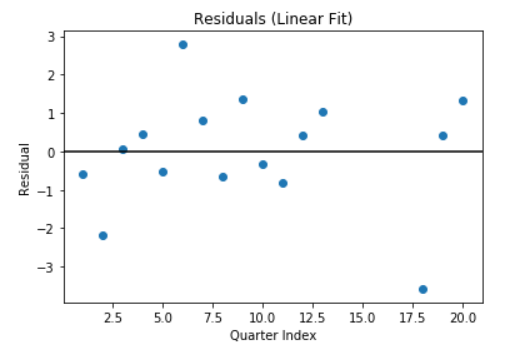

The slope was found to be -0.017336448598130813. A linear trend does not make sense for this type of data. While a linear model is a constant rate of change over time, GDP is not constant, it fluctuates and cycles in response to real-world situations like economic policies. A linear model requires the assumptions that GDP and time have a linear relationship, which is not true. It also assumes that the 2020 Q2 is not part of a pattern, and is instead a random event. 

Part C - Method Justification

1.

For a policymaker who needs to estimate GDP growth for a quarter between two known data points, I would recommend the cubic spline method. Cubic splines pass through all data points exactly, which makes them very reliable for interpolation. They are also continuous in the first and second derivatives, creating smooth transitions between points without sharp turns or fluctuations. Cubic splines are piecewise, so if any outliers are present, the effects of them are constrained to the intervals near them, mitigating their influence on the rest of the curve.

2.

The Big O notation is a way of showing how fast an algorithm gets slower as you give it more data. It focuses on how the runtime grows as the input size increases. For cubic spline interpolation, a tridiagonal linear system can be solved using the Thomas algorithm, solvable in linear time because each row only interacts with its neighbors. For Polynomial fitting, we fixed the degree at 4, which means that there are only 5 columns, so solving the 5x5 system is constant time because the size does not grow. For least squares linear regression, I only need to compute simple sums, so it has linear time.

The Big O analysis does not change my recommendation. All three methods are fast enough, so runtime is not a limiting factor. I chose my recommendation on model behavior, not computational cost.

Conclusion

The cubic spline interpolation performed the best for interpolation, because it passes exactly through all the data points while maintaining smoothness and stability at local intervals. A limitation of this model is that it can react dramatically to extreme local events. For trend analysis, the degree-4 polynomial fit gave a better representation of the overall trend because it smoothed out local fluctuations. A limitation of this model is that it will miss sharp turns and become unstable the higher degree you go. The linear least squares model is perfect when data approximately follows a linear trend, but only when the data follows this trend.